# Projet AfriMarket — Analyse stratégique des données e-commerce

**Rôle** : Data Analyst
**Entreprise** : AfriMarket (e-commerce panafricain — Électronique, Mode, Beauté, Maison)
**Période analysée** : 6 mois d'activité commerciale (juillet → décembre 2025)

Ce notebook couvre, dans l'ordre demandé par la direction :
1. Audit & compréhension des données
2. Data cleaning
3. Feature engineering
4. Analyses (performance globale, catégorie, géographie, marketing, clients)
5. Visualisations
6. Synthèse des recommandations stratégiques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import warnings

warnings.filterwarnings("ignore")
pio.renderers.default = "png"  # rendu statique fiable dans le notebook exporté
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

RAW_PATH = r"c:\Users\Lbzr\Desktop\FORMATION CLAUDE & AI BY AKSANTE\Jour 3\AfriMarket\data\afrimarket_dataset_senior.csv"
CLEAN_PATH = r"c:\Users\Lbzr\Desktop\FORMATION CLAUDE & AI BY AKSANTE\Jour 3\AfriMarket\data\df_clean.csv"

## 1. Audit & compréhension des données

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print("Dimensions :", df_raw.shape)
df_raw.head()

Dimensions : (10100, 14)


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


In [3]:
print("Types de données :")
print(df_raw.dtypes)

Types de données :
id_commande             str
date_commande           str
id_client               str
ville                   str
categorie               str
nom_produit             str
prix_unitaire       float64
quantite              int64
remise              float64
cout_livraison      float64
methode_paiement        str
canal_marketing         str
cout_marketing      float64
statut_commande         str
dtype: object


In [4]:
print("Valeurs manquantes par colonne :")
print(df_raw.isna().sum())

Valeurs manquantes par colonne :
id_commande         0
date_commande       0
id_client           0
ville               0
categorie           0
nom_produit         0
prix_unitaire       0
quantite            0
remise              0
cout_livraison      0
methode_paiement    0
canal_marketing     0
cout_marketing      0
statut_commande     0
dtype: int64


In [5]:
n_dup_full = df_raw.duplicated().sum()
n_dup_id = df_raw.duplicated(subset=["id_commande"]).sum()
print(f"Lignes strictement dupliquées : {n_dup_full}")
print(f"Doublons sur id_commande : {n_dup_id}")

Lignes strictement dupliquées : 100
Doublons sur id_commande : 100


In [6]:
print("Valeurs de 'ville' :")
print(df_raw["ville"].value_counts())
print("\nValeurs de 'categorie' :")
print(df_raw["categorie"].value_counts())
print("\nValeurs de 'statut_commande' :")
print(df_raw["statut_commande"].value_counts())

Valeurs de 'ville' :
ville
Kinshasa       2349
Abidjan        1886
Douala         1449
Dakar          1434
Lomé            735
Cotonou         677
Kinshassa       605
Libreville      493
Brazzaville     472
Name: count, dtype: int64

Valeurs de 'categorie' :
categorie
Mode            3005
Électronique    2638
Maison          1948
Beauté          1903
electronique     606
Name: count, dtype: int64

Valeurs de 'statut_commande' :
statut_commande
Livrée       9080
retournée     826
Annulée       194
Name: count, dtype: int64


In [7]:
print("prix_unitaire — statistiques :")
print(df_raw["prix_unitaire"].describe())
print("\nCommandes à prix négatif :", (df_raw["prix_unitaire"] < 0).sum())

print("\nquantite — statistiques :")
print(df_raw["quantite"].describe())
print("Commandes à quantité = 0 :", (df_raw["quantite"] == 0).sum())

print("\nremise — statistiques :")
print(df_raw["remise"].describe())
print("Remises négatives :", (df_raw["remise"] < 0).sum())

prix_unitaire — statistiques :
count    10100.000000
mean       140.493353
std        172.031607
min        -50.000000
25%         28.057500
50%         52.975000
75%        201.885000
max        915.860000
Name: prix_unitaire, dtype: float64

Commandes à prix négatif : 632

quantite — statistiques :
count    10100.000000
mean         1.866040
std          0.920966
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: quantite, dtype: float64
Commandes à quantité = 0 : 608

remise — statistiques :
count    10100.000000
mean         0.111422
std          0.098352
min         -0.100000
25%          0.050000
50%          0.090000
75%          0.190000
max          0.300000
Name: remise, dtype: float64
Remises négatives : 614


### Synthèse de l'audit — problèmes détectés

| Problème | Détail | Volume |
|---|---|---|
| Doublons exacts | Même `id_commande` répété avec les mêmes valeurs | 100 lignes (~1%) |
| Ville mal orthographiée | `Kinshassa` au lieu de `Kinshasa` | 605 lignes |
| Catégorie incohérente | `electronique` (minuscule, sans accent) au lieu de `Électronique` | 606 lignes |
| Statut incohérent | `retournée` (minuscule) au lieu de `Retournée` | 826 lignes |
| Remises négatives | `remise` < 0, impossible en pratique (borne théorique [0, 0.30]) | 614 lignes |
| Prix aberrants | `prix_unitaire` négatif, dont de nombreuses valeurs sentinelles exactes à **-50.00** | 632 lignes |
| Quantités nulles | `quantite` = 0 → commande sans article, incohérent avec un statut "Livrée"/"Retournée" | 608 lignes |
| Dates | Format déjà homogène `YYYY-MM-DD`, période 2025-07-01 → 2025-12-31 (6 mois, cohérent avec le brief) | — |
| Valeurs manquantes | Aucune valeur `NaN` native détectée dans le fichier brut | 0 |

**Décisions de nettoyage retenues** (détaillées section 2) :
- Suppression des doublons stricts.
- Harmonisation villes / catégories / statuts par mapping.
- `remise` négative → valeur absolue puis plafonnée à la borne max observée (0.30).
- `prix_unitaire` négatif → traité comme donnée invalide (remplacé par la **médiane de la catégorie**, plus robuste qu'une moyenne face aux valeurs extrêmes).
- `quantite` = 0 → commandes supprimées de `df_clean` (aucune activité économique réelle, incohérentes avec un statut de commande finalisée).

## 2. Data Cleaning

In [8]:
df = df_raw.copy()

# --- Doublons ---
before = len(df)
df = df.drop_duplicates(subset=["id_commande"], keep="first")
print(f"Doublons supprimés : {before - len(df)}")

# --- Dates ---
df["date_commande"] = pd.to_datetime(df["date_commande"], format="%Y-%m-%d")

# --- Villes ---
ville_map = {"Kinshassa": "Kinshasa"}
df["ville"] = df["ville"].replace(ville_map).str.strip()

# --- Catégories ---
categorie_map = {"electronique": "Électronique"}
df["categorie"] = df["categorie"].replace(categorie_map).str.strip()

# --- Statuts ---
statut_map = {"retournée": "Retournée", "Livrée": "Livrée", "Annulée": "Annulée"}
df["statut_commande"] = df["statut_commande"].replace(statut_map).str.strip()

# --- Remises négatives ---
df["remise"] = df["remise"].abs().clip(upper=0.30)

# --- Prix aberrants (négatifs) → médiane de la catégorie (post-harmonisation) ---
median_price_by_cat = df.loc[df["prix_unitaire"] >= 0].groupby("categorie")["prix_unitaire"].median()
mask_bad_price = df["prix_unitaire"] < 0
df.loc[mask_bad_price, "prix_unitaire"] = df.loc[mask_bad_price, "categorie"].map(median_price_by_cat)
print(f"Prix négatifs corrigés (médiane catégorie) : {mask_bad_price.sum()}")

# --- Quantités nulles → suppression (pas d'activité économique réelle) ---
before = len(df)
df = df[df["quantite"] > 0].copy()
print(f"Commandes à quantité nulle supprimées : {before - len(df)}")

df_clean = df.reset_index(drop=True)
print("\nDimensions finales df_clean :", df_clean.shape)
df_clean.head()

Doublons supprimés : 100
Prix négatifs corrigés (médiane catégorie) : 622
Commandes à quantité nulle supprimées : 600

Dimensions finales df_clean : (9400, 14)


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée
3,CMD100005,2025-10-17,C0079,Dakar,Maison,Produit_Maison_7,71.17,3,0.10,8.63,Virement,Instagram Ads,5.45,Livrée
4,CMD100006,2025-07-24,C0183,Abidjan,Mode,Produit_Mode_3,23.04,3,0.10,3.59,Virement,Instagram Ads,9.23,Livrée


In [9]:
# Vérifications post-nettoyage
assert df_clean.duplicated(subset=["id_commande"]).sum() == 0
assert (df_clean["prix_unitaire"] < 0).sum() == 0
assert (df_clean["remise"] < 0).sum() == 0
assert (df_clean["quantite"] == 0).sum() == 0
assert set(df_clean["ville"].unique()) == {"Kinshasa","Abidjan","Douala","Dakar","Lomé","Cotonou","Libreville","Brazzaville"}
assert set(df_clean["categorie"].unique()) == {"Mode","Électronique","Maison","Beauté"}
assert set(df_clean["statut_commande"].unique()) == {"Livrée","Retournée","Annulée"}
print("Toutes les vérifications de qualité sont passées.")

Toutes les vérifications de qualité sont passées.


## 3. Feature Engineering

**Hypothèses de marge documentées** (le dataset ne fournit pas de coût d'achat) : un taux de marge brute
a été estimé par catégorie à partir de références sectorielles e-commerce classiques :
- Électronique : 20% (marché concurrentiel, faible marge)
- Mode : 45%
- Beauté : 50%
- Maison : 35%

**Règle métier revenus/retours** : une commande **Annulée** ne génère aucun chiffre d'affaires.
Une commande **Retournée** génère un CA (elle a été livrée puis retournée) mais son profit net
est pénalisé : la marge brute est annulée et seuls les coûts logistiques/marketing restent à charge
(perte sèche), ce qui reflète l'impact réel d'un retour sur la rentabilité.

In [10]:
MARGE_RATES = {"Électronique": 0.20, "Mode": 0.45, "Beauté": 0.50, "Maison": 0.35}

df_clean["chiffre_affaires"] = np.where(
    df_clean["statut_commande"] == "Annulée",
    0.0,
    df_clean["prix_unitaire"] * df_clean["quantite"] * (1 - df_clean["remise"]),
)

df_clean["marge_brute_estimee"] = df_clean["chiffre_affaires"] * df_clean["categorie"].map(MARGE_RATES)

df_clean["indicateur_retour"] = (df_clean["statut_commande"] == "Retournée").astype(int)

df_clean["profit_net_estime"] = (
    df_clean["marge_brute_estimee"]
    - df_clean["cout_livraison"]
    - df_clean["cout_marketing"]
    - np.where(df_clean["indicateur_retour"] == 1, df_clean["marge_brute_estimee"], 0.0)
)

df_clean["mois"] = df_clean["date_commande"].dt.to_period("M").astype(str)

df_clean["nombre_commandes_par_client"] = df_clean.groupby("id_client")["id_commande"].transform("count")

df_clean["valeur_vie_client"] = df_clean.groupby("id_client")["chiffre_affaires"].transform("sum")

df_clean.to_csv(CLEAN_PATH, index=False)
print("df_clean sauvegardé :", CLEAN_PATH)
df_clean[["chiffre_affaires","marge_brute_estimee","profit_net_estime","mois",
          "indicateur_retour","nombre_commandes_par_client","valeur_vie_client"]].describe()

df_clean sauvegardé : c:\Users\Lbzr\Desktop\FORMATION CLAUDE & AI BY AKSANTE\Jour 3\AfriMarket\data\df_clean.csv


,chiffre_affaires,marge_brute_estimee,profit_net_estime,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
count,9400.000000,9400.000000,9400.000000,9400.000000,9400.000000,9400.000000
mean,266.736722,66.708862,45.783805,0.081383,12.383191,3314.868264
std,346.768021,67.035952,65.612382,0.273437,7.268048,2303.671559
min,0.000000,0.000000,-28.930000,0.000000,1.000000,0.000000
25%,45.789350,20.155939,2.171271,0.000000,4.000000,1236.656300
50%,100.424000,41.077680,22.278092,0.000000,14.000000,3322.982500
75%,351.767250,89.780197,66.683060,0.000000,18.000000,4780.540400
max,2315.085300,463.017060,455.087060,1.000000,29.000000,11553.739200


## 4. Analyses stratégiques
### 4.1 Performance globale

In [11]:
ca_total = df_clean["chiffre_affaires"].sum()
profit_total = df_clean["profit_net_estime"].sum()
panier_moyen = df_clean.loc[df_clean["statut_commande"] != "Annulée", "chiffre_affaires"].mean()
taux_annulation = (df_clean["statut_commande"] == "Annulée").mean()
taux_retour = (df_clean["statut_commande"] == "Retournée").mean()

print(f"CA total                : {ca_total:,.0f} $")
print(f"Profit net estimé total  : {profit_total:,.0f} $")
print(f"Panier moyen             : {panier_moyen:,.2f} $")
print(f"Taux d'annulation        : {taux_annulation:.1%}")
print(f"Taux de retour           : {taux_retour:.1%}")

CA total                : 2,507,325 $
Profit net estimé total  : 430,368 $
Panier moyen             : 272.03 $
Taux d'annulation        : 1.9%
Taux de retour           : 8.1%


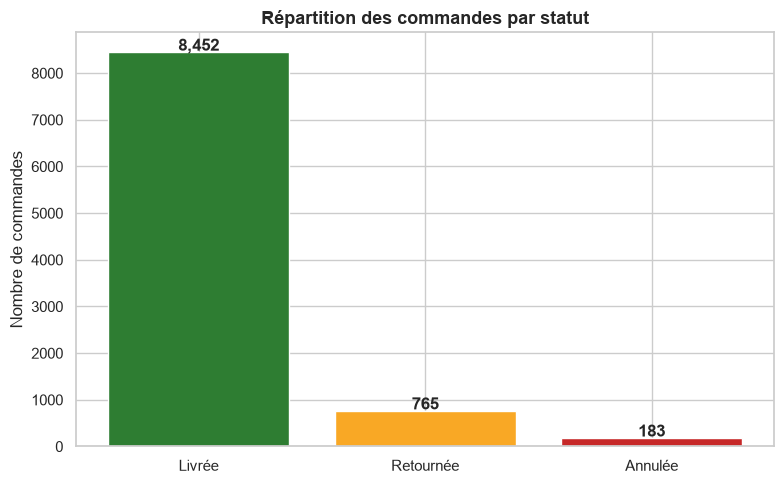

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
statut_counts = df_clean["statut_commande"].value_counts()
colors = {"Livrée": "#2E7D32", "Retournée": "#F9A825", "Annulée": "#C62828"}
ax.bar(statut_counts.index, statut_counts.values, color=[colors[s] for s in statut_counts.index])
ax.set_title("Répartition des commandes par statut", fontsize=13, fontweight="bold")
ax.set_ylabel("Nombre de commandes")
for i, v in enumerate(statut_counts.values):
    ax.text(i, v + 30, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Analyse par catégorie
**Question stratégique : quelle catégorie doit être priorisée ou optimisée ?**

In [13]:
cat_perf = df_clean.groupby("categorie").agg(
    ca=("chiffre_affaires", "sum"),
    marge=("marge_brute_estimee", "sum"),
    profit=("profit_net_estime", "sum"),
    taux_retour=("indicateur_retour", "mean"),
    n_commandes=("id_commande", "count"),
).sort_values("ca", ascending=False)
cat_perf["marge_pct"] = cat_perf["marge"] / cat_perf["ca"]
cat_perf

,ca,marge,profit,taux_retour,n_commandes,marge_pct
categorie,,,,,,
Électronique,1.870410e+06,374081.99450,277351.009300,0.138390,3006,0.20
Maison,3.745005e+05,131075.18137,100241.949795,0.049472,1799,0.35
Mode,1.860245e+05,83711.00979,39381.020710,0.074374,2837,0.45
Beauté,7.639023e+04,38195.11570,13393.789850,0.027873,1758,0.50


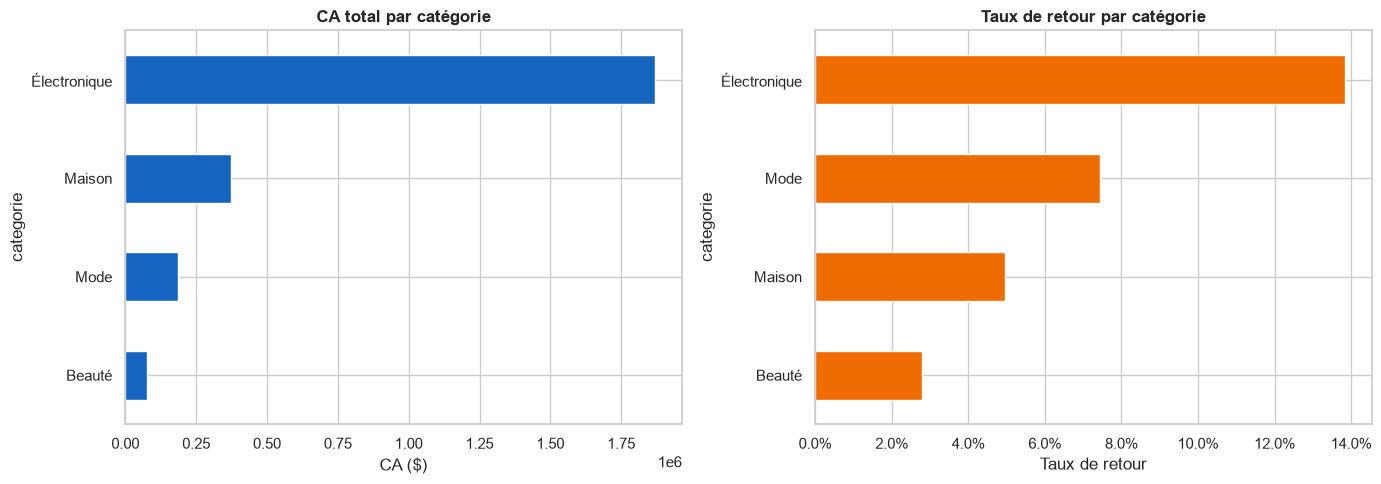

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_perf["ca"].sort_values().plot(kind="barh", ax=axes[0], color="#1565C0")
axes[0].set_title("CA total par catégorie", fontweight="bold")
axes[0].set_xlabel("CA ($)")

cat_perf["taux_retour"].sort_values().plot(kind="barh", ax=axes[1], color="#EF6C00")
axes[1].set_title("Taux de retour par catégorie", fontweight="bold")
axes[1].set_xlabel("Taux de retour")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

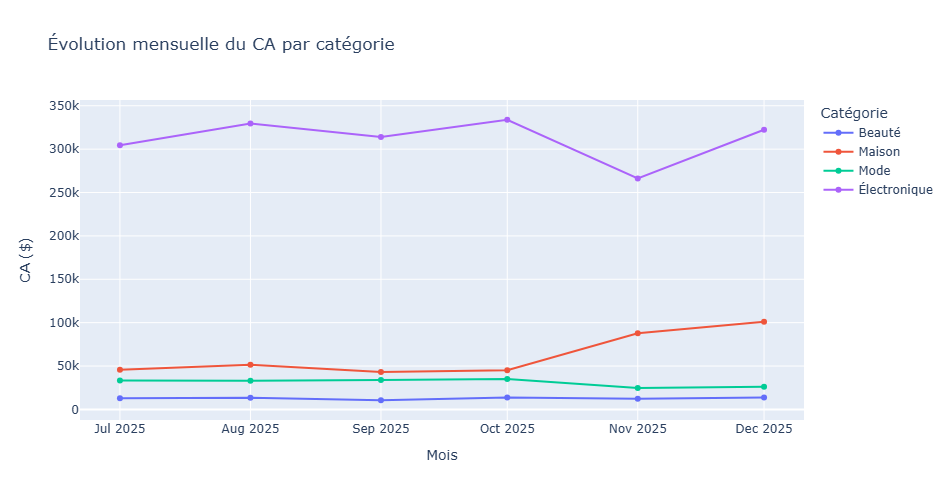

In [15]:
evol_cat = df_clean.groupby(["mois", "categorie"])["chiffre_affaires"].sum().reset_index()
fig = px.line(evol_cat, x="mois", y="chiffre_affaires", color="categorie", markers=True,
              title="Évolution mensuelle du CA par catégorie",
              labels={"chiffre_affaires": "CA ($)", "mois": "Mois", "categorie": "Catégorie"})
fig.update_layout(width=950, height=500)
fig.show()

### 4.3 Analyse géographique
**Question stratégique : où devons-nous investir davantage ?**

In [16]:
ville_perf = df_clean.groupby("ville").agg(
    ca=("chiffre_affaires", "sum"),
    profit=("profit_net_estime", "sum"),
    taux_annulation=("statut_commande", lambda s: (s == "Annulée").mean()),
    n_commandes=("id_commande", "count"),
).sort_values("ca", ascending=False)
ville_perf

,ca,profit,taux_annulation,n_commandes
ville,,,,
Kinshasa,752095.69530,130469.834040,0.002570,2724
Abidjan,500916.33275,85191.469080,0.000000,1756
Dakar,348707.39760,60098.823330,0.000000,1346
Douala,331903.30795,55966.223795,0.129222,1362
Lomé,184253.82370,32889.264825,0.000000,682
Cotonou,159153.76310,28412.790090,0.000000,631
Libreville,124149.33040,19652.422320,0.000000,467
Brazzaville,106145.53750,17686.942175,0.000000,432


In [17]:
croissance = df_clean.groupby(["ville", "mois"])["chiffre_affaires"].sum().reset_index()
croissance["mois_num"] = pd.to_datetime(croissance["mois"]).rank(method="dense")
premier_mois = croissance.groupby("ville").first()["chiffre_affaires"]
dernier_mois = croissance.groupby("ville").last()["chiffre_affaires"]
ville_perf["croissance_mensuelle_pct"] = ((dernier_mois - premier_mois) / premier_mois).reindex(ville_perf.index)
ville_perf

,ca,profit,taux_annulation,n_commandes,croissance_mensuelle_pct
ville,,,,,
Kinshasa,752095.69530,130469.834040,0.002570,2724,0.206614
Abidjan,500916.33275,85191.469080,0.000000,1756,0.223793
Dakar,348707.39760,60098.823330,0.000000,1346,-0.116243
Douala,331903.30795,55966.223795,0.129222,1362,0.763069
Lomé,184253.82370,32889.264825,0.000000,682,0.110981
Cotonou,159153.76310,28412.790090,0.000000,631,0.040554
Libreville,124149.33040,19652.422320,0.000000,467,-0.462771
Brazzaville,106145.53750,17686.942175,0.000000,432,0.600895


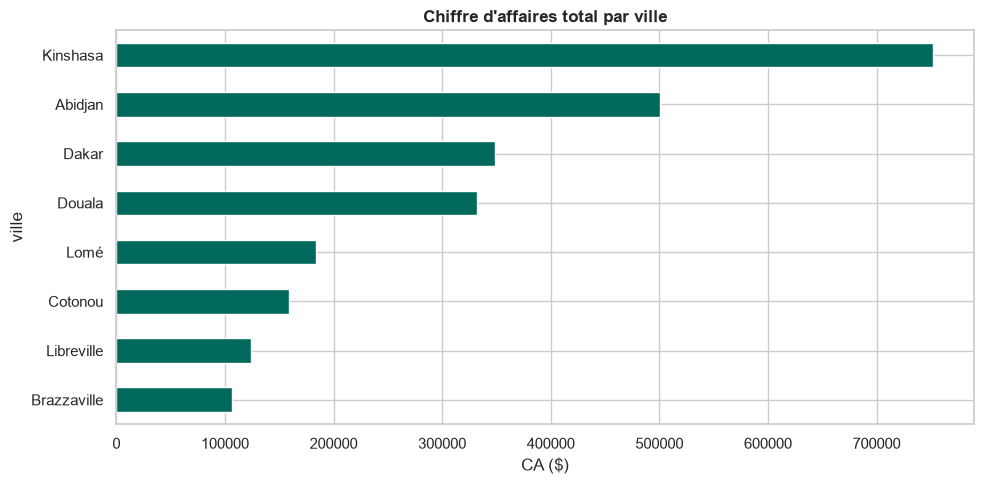

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ville_perf["ca"].sort_values().plot(kind="barh", ax=ax, color="#00695C")
ax.set_title("Chiffre d'affaires total par ville", fontweight="bold")
ax.set_xlabel("CA ($)")
plt.tight_layout()
plt.show()

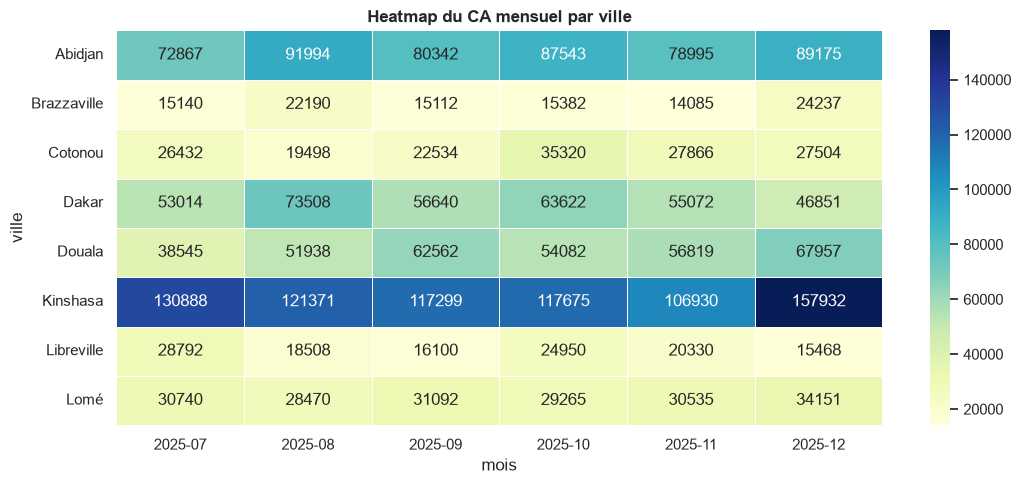

In [19]:
pivot_ville_mois = df_clean.pivot_table(index="ville", columns="mois", values="chiffre_affaires", aggfunc="sum")
plt.figure(figsize=(11, 5))
sns.heatmap(pivot_ville_mois, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Heatmap du CA mensuel par ville", fontweight="bold")
plt.tight_layout()
plt.show()

### 4.4 Analyse marketing
**Question stratégique : quel canal mérite plus de budget ? Lequel doit être optimisé ou réduit ?**

ROI = (Revenus − Coût marketing) / Coût marketing

In [20]:
canal_perf = df_clean.groupby("canal_marketing").agg(
    ca=("chiffre_affaires", "sum"),
    cout_marketing_total=("cout_marketing", "sum"),
    taux_retention=("nombre_commandes_par_client", lambda s: (s > 1).mean()),
).sort_values("ca", ascending=False)
canal_perf["roi"] = (canal_perf["ca"] - canal_perf["cout_marketing_total"]) / canal_perf["cout_marketing_total"]
canal_perf

,ca,cout_marketing_total,taux_retention,roi
canal_marketing,,,,
Instagram Ads,949839.28795,37637.07,0.949801,24.236802
Google Ads,664891.02730,13158.93,0.956958,49.527743
Email,532086.84580,2349.15,0.949842,225.501861
Influenceur,360508.02725,16359.59,0.950297,21.036495


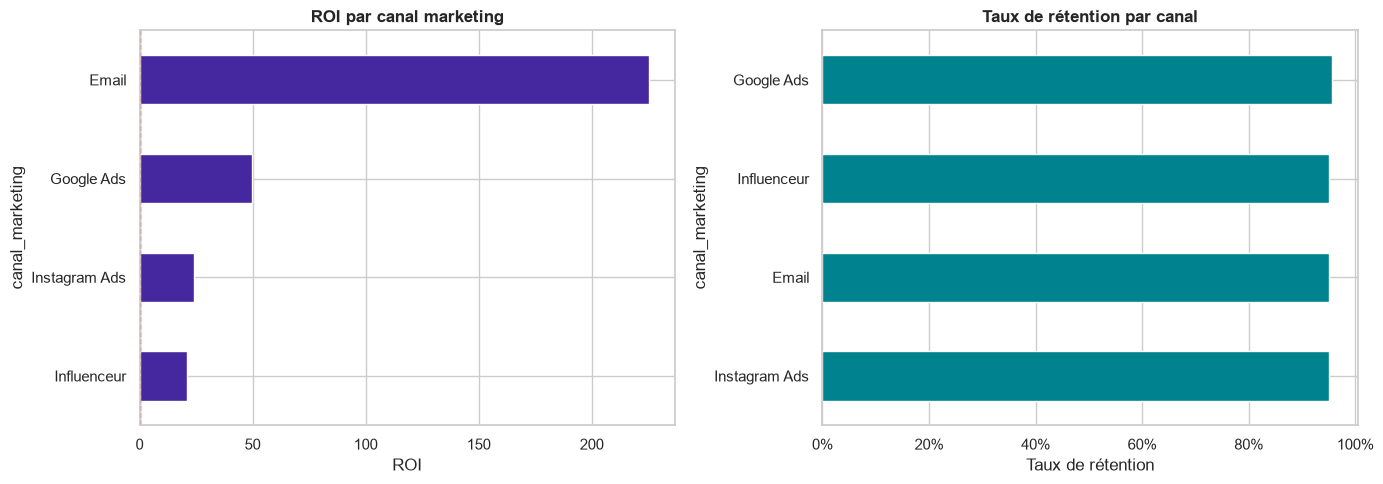

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
canal_perf["roi"].sort_values().plot(kind="barh", ax=axes[0], color="#4527A0")
axes[0].set_title("ROI par canal marketing", fontweight="bold")
axes[0].set_xlabel("ROI")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

canal_perf["taux_retention"].sort_values().plot(kind="barh", ax=axes[1], color="#00838F")
axes[1].set_title("Taux de rétention par canal", fontweight="bold")
axes[1].set_xlabel("Taux de rétention")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

### 4.5 Analyse clients
**Question stratégique : comment améliorer la rétention ?**

In [22]:
n_clients_total = df_clean["id_client"].nunique()
pct_recurrents = (df_clean.groupby("id_client")["id_commande"].count() > 1).mean()
print(f"Nombre total de clients : {n_clients_total}")
print(f"% clients récurrents (>1 commande) : {pct_recurrents:.1%}")

Nombre total de clients : 1747
% clients récurrents (>1 commande) : 74.0%


In [23]:
clv_client = df_clean.groupby("id_client")["chiffre_affaires"].sum().sort_values(ascending=False)
clv_client_cum = clv_client.cumsum() / clv_client.sum()
n_20pct = int(np.ceil(0.2 * len(clv_client)))
part_ca_top20 = clv_client_cum.iloc[n_20pct - 1]
print(f"Les {n_20pct} clients les plus rentables ({n_20pct/len(clv_client):.0%} de la base) "
      f"génèrent {part_ca_top20:.1%} du CA total.")

top10 = clv_client.head(10).rename("valeur_vie_client").reset_index()
top10

Les 350 clients les plus rentables (20% de la base) génèrent 64.5% du CA total.


,id_client,valeur_vie_client
0,C0157,11553.7392
1,C0266,10673.2270
2,C0120,9514.3431
3,C0003,9473.0849
4,C0051,9419.4902
5,C0379,8995.6496
6,C0114,8915.4355
7,C0184,8476.5419
8,C0067,8476.4071
9,C0364,8252.4673


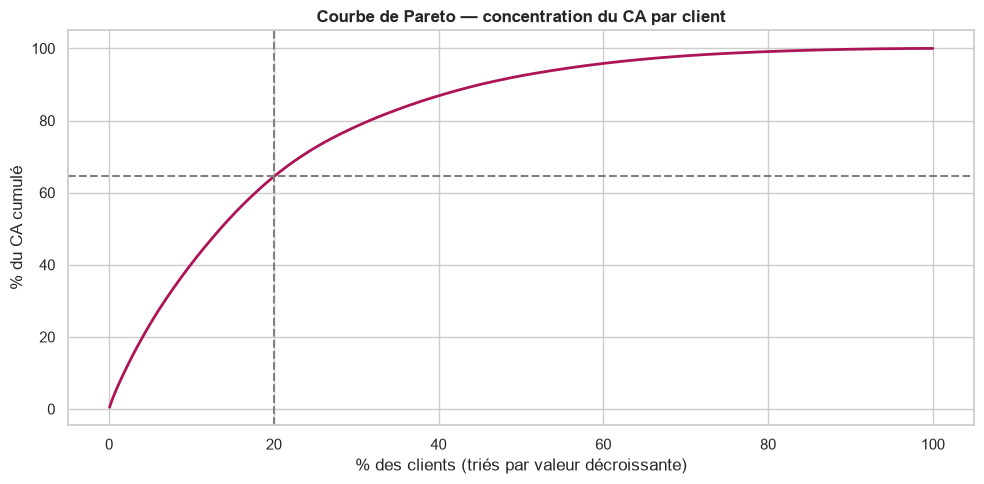

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, len(clv_client) + 1) / len(clv_client)
ax.plot(x * 100, clv_client_cum.values * 100, color="#AD1457", linewidth=2)
ax.axvline(20, color="gray", linestyle="--")
ax.axhline(part_ca_top20 * 100, color="gray", linestyle="--")
ax.set_title("Courbe de Pareto — concentration du CA par client", fontweight="bold")
ax.set_xlabel("% des clients (triés par valeur décroissante)")
ax.set_ylabel("% du CA cumulé")
plt.tight_layout()
plt.show()

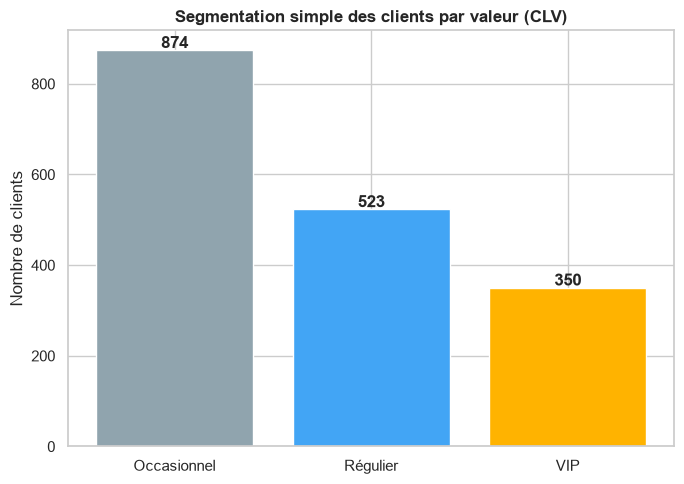

In [25]:
seg = pd.cut(
    df_clean.groupby("id_client")["chiffre_affaires"].sum(),
    bins=[-0.01, clv_client.quantile(0.5), clv_client.quantile(0.8), clv_client.max()],
    labels=["Occasionnel", "Régulier", "VIP"],
)
seg_counts = seg.value_counts().reindex(["Occasionnel", "Régulier", "VIP"])
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(seg_counts.index, seg_counts.values, color=["#90A4AE", "#42A5F5", "#FFB300"])
ax.set_title("Segmentation simple des clients par valeur (CLV)", fontweight="bold")
ax.set_ylabel("Nombre de clients")
for i, v in enumerate(seg_counts.values):
    ax.text(i, v + 5, f"{v}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Synthèse — 5 recommandations stratégiques

1. **Sécuriser la marge sur Électronique, pilier du CA mais maillon faible de la rentabilité.**
   Électronique pèse **74,6% du CA total** (1,87M$ / 2,51M$) mais affiche la marge la plus faible
   (20%) *et* le taux de retour le plus élevé (**13,8%**, quasi 2x supérieur à Mode). Toute action sur
   cette catégorie (négociation fournisseurs, réduction du taux de retour) a un effet de levier
   disproportionné sur le profit total.

2. **Traiter en priorité les retours Électronique**, cause principale du taux de retour global (8,1%).
   Chaque retour annule la marge brute tout en laissant les coûts logistiques/marketing à charge :
   un audit qualité/SAV ciblé sur cette catégorie (fiabilité produit, description, SAV) est le levier
   de rentabilité le plus direct identifié dans ce dataset.

3. **Réallouer le budget marketing d'Instagram Ads/Influenceur vers Email et Google Ads.**
   Email affiche un ROI de **225x** pour seulement 2 349$ investis (le plus petit budget des 4 canaux),
   alors qu'Instagram Ads consomme 37 637$ (le plus gros budget) pour un ROI de seulement 24x, et
   Influenceur le ROI le plus faible (21x). Un rééquilibrage progressif du budget vers Email/Google Ads
   (ROI 49x) sans couper Instagram (volume de CA le plus élevé) maximiserait le retour marginal.

4. **Investir sur Kinshasa/Brazzaville, corriger Douala, réévaluer Libreville.** Kinshasa concentre déjà
   le plus fort CA et profit (752k$ / 130k$) et doit rester prioritaire. Douala combine la **meilleure
   croissance (+76%)** et un **taux d'annulation anormal de 12,9%** (vs quasi 0% partout ailleurs) — un
   problème opérationnel (paiement, stock, livraison) freine probablement une ville par ailleurs très
   prometteuse et mérite une investigation immédiate. Libreville recule (-46%) et doit être réévaluée
   avant tout investissement marketing supplémentaire. Brazzaville (+60%) est un marché émergent à
   surveiller.

5. **Lancer un programme de fidélisation VIP ciblé sur le Pareto client.** 74% des 1 747 clients sont
   déjà récurrents, mais les 350 clients les plus rentables (20% de la base) concentrent **64,5% du
   CA total**. Protéger et développer ce segment (offres exclusives, service prioritaire) offre un ROI
   de rétention supérieur à l'acquisition de nouveaux clients occasionnels.

## Conclusion business orientée action

Avec 2,51M$ de CA et 430k$ de profit net estimé sur 6 mois, AfriMarket a un modèle rentable mais avec
trois fuites de rentabilité claires et quantifiées : (1) un taux de retour Électronique presque double
de la moyenne qui érode la marge de sa catégorie la plus vendue, (2) un budget marketing mal réparti —
Email est sous-investi de manière flagrante au regard de son ROI (225x) pendant qu'Instagram Ads absorbe
l'essentiel du budget pour un rendement dix fois plus faible, et (3) un problème opérationnel localisé à
Douala (12,9% d'annulation) qui freine la ville à plus forte croissance du réseau.

**Plan d'action à 30 jours :**
1. Semaine 1 : audit qualité/SAV Électronique + audit opérationnel Douala (cause des annulations).
2. Semaine 2 : transfert de 15-20% du budget Instagram Ads/Influenceur vers Email/Google Ads (test A/B
   sur un mois avant généralisation).
3. Semaine 3-4 : lancement pilote programme VIP sur les 350 clients Pareto identifiés.

Ces trois actions ciblent directement les 4 signaux remontés par la direction (variations de CA, taux
de retour, dépenses marketing, écarts de performance géographique) avec un impact mesurable dès le mois
suivant, sans nécessiter d'investissement supplémentaire net (réallocation, pas d'augmentation budgétaire).